# Exploratory Data Analysis

Goal: understand household electricity consumption patterns before
feature engineering and forecasting.

Questions:
- What does the target distribution look like?
- How does consumption change over time?
- Are there hourly, daily, weekly, or monthly patterns?
- How are the electrical measurements related?
- Are there extreme values or unusual periods?

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
data_path = Path("../data/processed/household_power_validated.parquet")

df = pd.read_parquet(data_path)

print(df.shape)
df.head()

(2075259, 10)


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,datetime
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0,2006-12-16 17:24:00
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0,2006-12-16 17:25:00
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0,2006-12-16 17:26:00
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0,2006-12-16 17:27:00
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0,2006-12-16 17:28:00


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 10 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   Date                   str           
 1   Time                   str           
 2   Global_active_power    float64       
 3   Global_reactive_power  float64       
 4   Voltage                float64       
 5   Global_intensity       float64       
 6   Sub_metering_1         float64       
 7   Sub_metering_2         float64       
 8   Sub_metering_3         float64       
 9   datetime               datetime64[us]
dtypes: datetime64[us](1), float64(7), str(2)
memory usage: 191.9 MB


In [4]:
print("Start:", df["datetime"].min())
print("End:", df["datetime"].max())
print("Sorted:", df["datetime"].is_monotonic_increasing)

Start: 2006-12-16 17:24:00
End: 2010-11-26 21:02:00
Sorted: True


## Global Active Power

In [5]:
df["Global_active_power"].describe()

count    2.049280e+06
mean     1.091615e+00
std      1.057294e+00
min      7.600000e-02
25%      3.080000e-01
50%      6.020000e-01
75%      1.528000e+00
max      1.112200e+01
Name: Global_active_power, dtype: float64

In [6]:
# check missing

target = df["Global_active_power"]

print("Missing:", target.isna().sum())
print("Missing %:", target.isna().mean() * 100)

Missing: 25979
Missing %: 1.2518437457686005


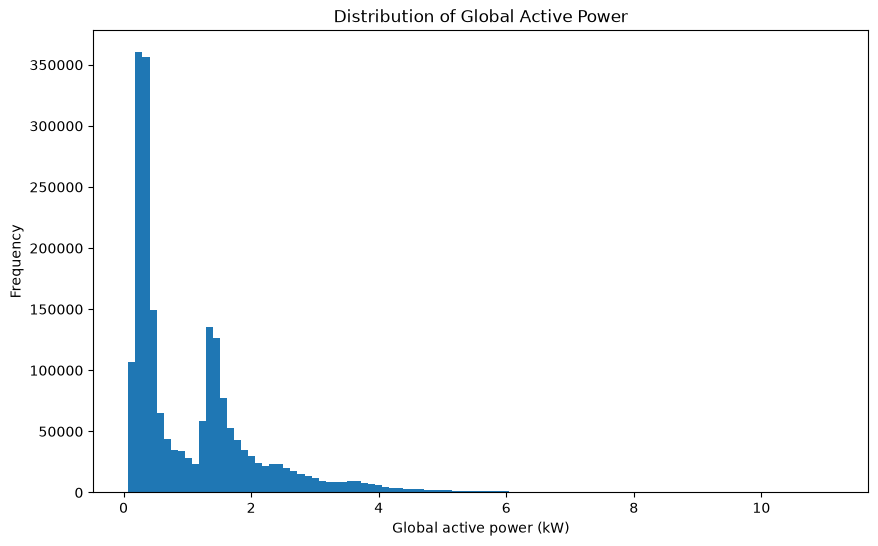

In [7]:
# plot distribution

plt.figure(figsize=(10, 6))

plt.hist(
    df["Global_active_power"].dropna(),
    bins=100
)

plt.xlabel("Global active power (kW)")
plt.ylabel("Frequency")
plt.title("Distribution of Global Active Power")

plt.show()

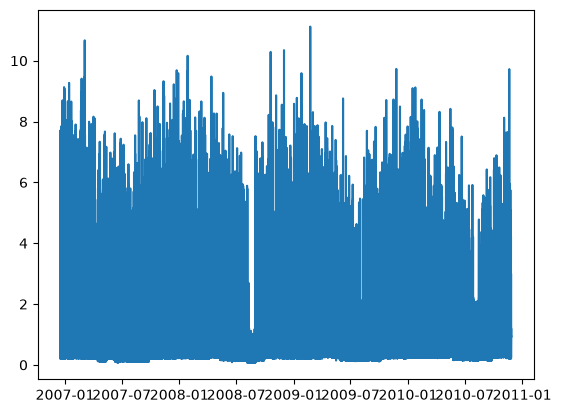

In [8]:
# time series

plt.plot(df["datetime"], df["Global_active_power"])

In [9]:
start = df["datetime"].min()
end = start + pd.Timedelta(days=7)

week = df[
    (df["datetime"] >= start)
    & (df["datetime"] < end)
]

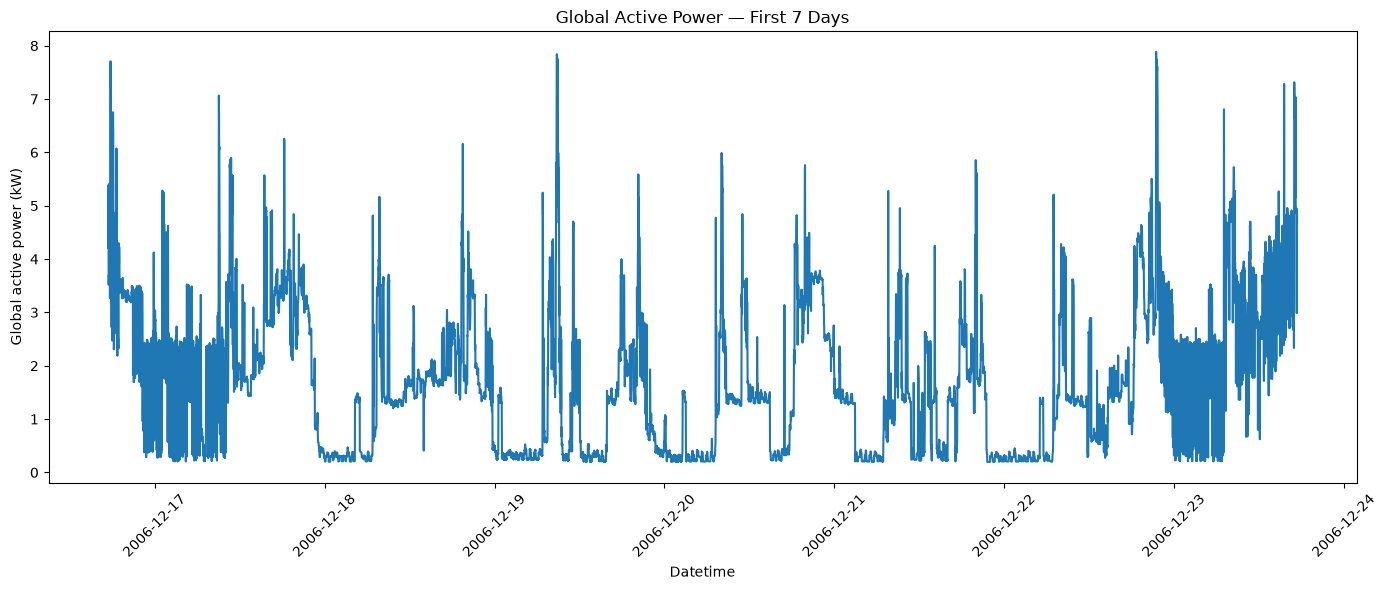

In [10]:
plt.figure(figsize=(14, 6))

plt.plot(
    week["datetime"],
    week["Global_active_power"]
)

plt.xlabel("Datetime")
plt.ylabel("Global active power (kW)")
plt.title("Global Active Power — First 7 Days")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [11]:
# notice:
# baseline consumption
# spikes
# quiet overnight periods
# possible morning/evening peaks
# repeating daily behavior